# Notebook 16: Deep Learning Model Evaluation & Error Analysis



## 1. Data, model, and evaluation plan
We create train/validation partitions from Fashion-MNIST's training split. The test split is not used for model decisions. Normalization maps grayscale pixels to approximately [-1, 1].

For a fair training-accuracy estimate, metrics are computed in evaluation mode after each epoch; this disables dropout and avoids mixing training-time behavior with evaluation.

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classes = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_all = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_all = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_subset = Subset(train_all, range(12000))
train_ds, val_ds = random_split(train_subset, [10000, 2000], generator=torch.Generator().manual_seed(SEED))
test_ds = Subset(test_all, range(2000))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
train_eval_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
print(f'Device: {device}; train={len(train_ds)}, validation={len(val_ds)}, test={len(test_ds)}')

Device: cpu; train=10000, validation=2000, test=2000


## 2. Train a reference CNN and record metrics
The model has two convolution/pooling stages followed by a classifier. Cross-entropy consumes logits directly; do not apply softmax before this loss. The run below captures training and validation loss and accuracy each epoch.

In [2]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(32 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.25), nn.Linear(128, 10))
    def forward(self, x):
        return self.classifier(self.features(x))

model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def evaluate(model, loader):
    model.eval(); loss_sum = 0.0; correct = 0; count = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images); loss_sum += criterion(logits, labels).item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item(); count += labels.size(0)
    return loss_sum / count, correct / count

history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': []}
for epoch in range(3):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(); loss = criterion(model(images), labels); loss.backward(); optimizer.step()
    train_loss, train_acc = evaluate(model, train_eval_loader)
    val_loss, val_acc = evaluate(model, val_loader)
    for key, value in [('train_loss', train_loss), ('val_loss', val_loss), ('train_accuracy', train_acc), ('val_accuracy', val_acc)]:
        history[key].append(value)
    print(f'Epoch {epoch+1}: train loss={train_loss:.4f}, acc={train_acc:.3f} | val loss={val_loss:.4f}, acc={val_acc:.3f}')

Epoch 1: train loss=0.5791, acc=0.786 | val loss=0.5752, acc=0.793
Epoch 2: train loss=0.4776, acc=0.825 | val loss=0.4951, acc=0.817
Epoch 3: train loss=0.4180, acc=0.851 | val loss=0.4472, acc=0.842


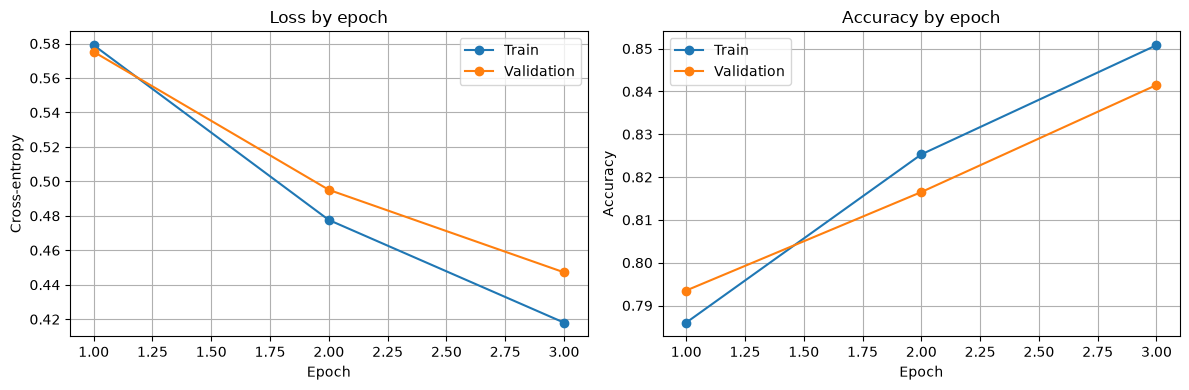

Final train-validation accuracy gap: 0.009
Diagnostic: no large accuracy gap is visible in this run; check whether both scores are adequate and whether more training helps.


In [3]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, history['train_loss'], marker='o', label='Train'); axes[0].plot(epochs, history['val_loss'], marker='o', label='Validation')
axes[0].set(title='Loss by epoch', xlabel='Epoch', ylabel='Cross-entropy'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(epochs, history['train_accuracy'], marker='o', label='Train'); axes[1].plot(epochs, history['val_accuracy'], marker='o', label='Validation')
axes[1].set(title='Accuracy by epoch', xlabel='Epoch', ylabel='Accuracy'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()
gap = history['train_accuracy'][-1] - history['val_accuracy'][-1]
print(f'Final train-validation accuracy gap: {gap:.3f}')
if history['train_accuracy'][-1] < 0.65 and history['val_accuracy'][-1] < 0.65:
    print('Diagnostic: both scores are modest; this short run may be underfit. Consider more epochs or capacity.')
elif gap > 0.08:
    print('Diagnostic: a sizable train advantage suggests possible overfitting; inspect the curves and consider regularization/data augmentation.')
else:
    print('Diagnostic: no large accuracy gap is visible in this run; check whether both scores are adequate and whether more training helps.')

## 3. Final test evaluation and class-wise results
Only after the diagnostic choices are complete, evaluate the held-out test subset. Precision, recall, and F1 reveal class-specific behavior that overall accuracy hides. The confusion matrix's rows are true classes and columns are predicted classes.

Test accuracy: 0.8310; test loss: 0.4469
              precision    recall  f1-score   support

 T-shirt/top      0.853     0.725     0.784       200
     Trouser      0.985     0.946     0.965       203
    Pullover      0.822     0.692     0.751       214
       Dress      0.804     0.842     0.823       190
        Coat      0.657     0.858     0.745       219
      Sandal      0.968     0.928     0.948       195
       Shirt      0.558     0.558     0.558       197
     Sneaker      0.926     0.870     0.897       200
         Bag      0.953     0.938     0.945       194
  Ankle boot      0.879     0.968     0.922       188

    accuracy                          0.831      2000
   macro avg      0.841     0.833     0.834      2000
weighted avg      0.839     0.831     0.832      2000



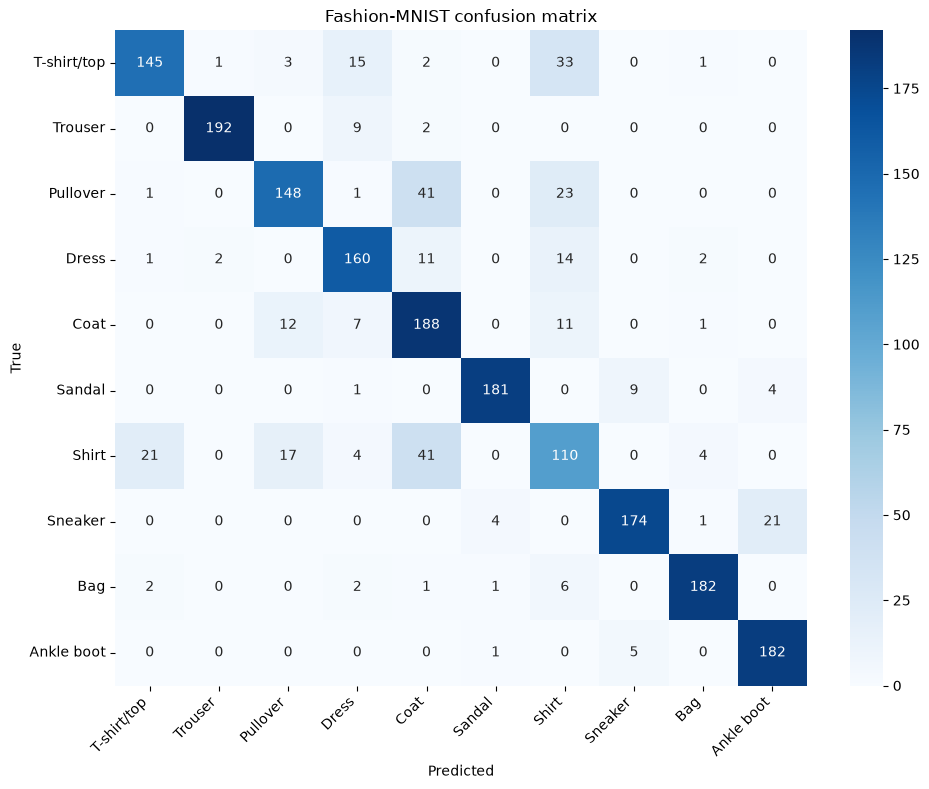

Lowest-recall classes: [('Shirt', np.float64(0.558)), ('Pullover', np.float64(0.692)), ('T-shirt/top', np.float64(0.725))]
Most common confusions (true -> predicted): [(np.int64(41), 'Shirt', 'Coat'), (np.int64(41), 'Pullover', 'Coat'), (np.int64(33), 'T-shirt/top', 'Shirt'), (np.int64(23), 'Pullover', 'Shirt'), (np.int64(21), 'Sneaker', 'Ankle boot')]


In [4]:
model.eval(); y_true = []; y_pred = []; test_loss_sum = 0.0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images); test_loss_sum += criterion(logits, labels).item() * labels.size(0)
        y_true.extend(labels.cpu().tolist()); y_pred.extend(logits.argmax(1).cpu().tolist())
print(f'Test accuracy: {accuracy_score(y_true, y_pred):.4f}; test loss: {test_loss_sum / len(test_ds):.4f}')
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0, digits=3))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8)); sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Fashion-MNIST confusion matrix'); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()
class_recall = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
print('Lowest-recall classes:', [(classes[i], round(class_recall[i], 3)) for i in np.argsort(class_recall)[:3]])
pairs = [(cm[i, j], classes[i], classes[j]) for i in range(10) for j in range(10) if i != j]
print('Most common confusions (true -> predicted):', sorted(pairs, reverse=True)[:5])

## 4. Inspect misclassified samples and explain error patterns
Similar garment silhouettes (for example, shirt, T-shirt, pullover, and coat) can be ambiguous even to a person. Inspect actual examples before attributing errors to the architecture: image resolution, label noise, class imbalance, and preprocessing can also contribute.

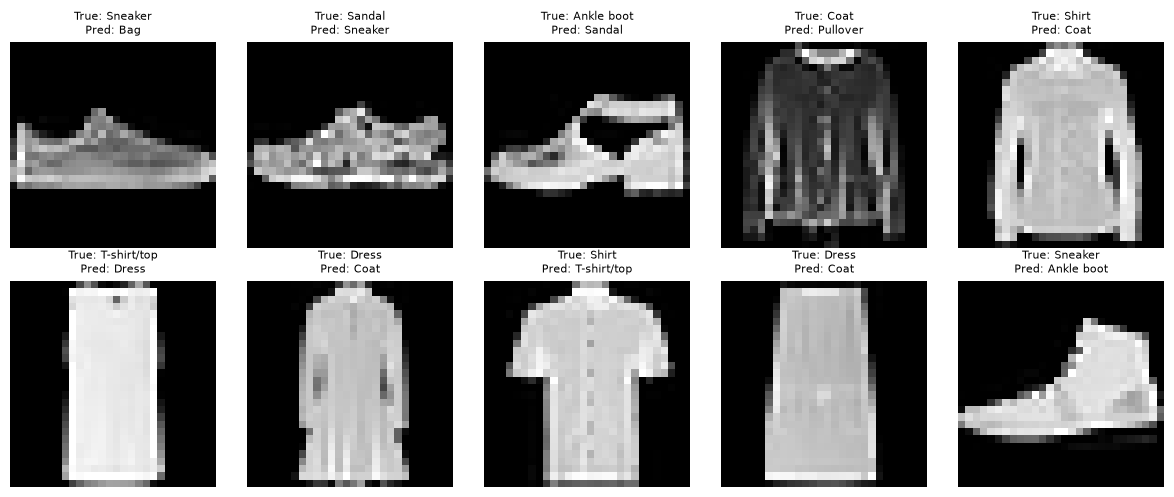

Misclassified samples: 338 / 2000


In [5]:
wrong = np.flatnonzero(np.array(y_true) != np.array(y_pred))
if len(wrong):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for ax, index in zip(axes.flat, wrong[:10]):
        image, actual = test_ds[index]
        ax.imshow(image.squeeze(), cmap='gray'); ax.set_title(f'True: {classes[actual]}\nPred: {classes[y_pred[index]]}', fontsize=8); ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No errors in this small test subset.')
print(f'Misclassified samples: {len(wrong)} / {len(y_true)}')

## 5. Explain why the model performed this way
Use your run's outputs to complete the diagnosis rather than assuming regularization or more layers always help.

- **Overfitting:** training metrics improve while validation metrics stall/worsen, leaving a sustained gap. Try dropout, weight decay, augmentation, or early stopping.
- **Underfitting:** both train and validation scores remain weak and close. Check optimization, increase training time/capacity, or improve inputs.
- **Class confusion:** inspect the largest off-diagonal cells and displayed examples; visually similar categories are expected to overlap.
- **Data-related causes:** low image resolution, ambiguous boundaries, label errors, and class imbalance. Check class counts and samples.
- **Model-related causes:** insufficient capacity/receptive field, optimization settings, or inadequate training. Compare alternatives on validation data.

The test subset is only 2,000 examples here, so scores have sampling uncertainty. Do not tune repeatedly against this test result; use the validation set for decisions.